In [2]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit import cost
from scipy import stats
from sympy import * 
import pandas as pd
from helpers import *
r = np.random 

## 3.1.1

In [3]:
r.seed(42)
N_points = 10000
N = 25
x_vals = np.sum(np.random.choice([-1, 1], size=(N_points, N)) / np.arange(1, N+1),axis=1)

In [4]:
print(np.min(x_vals), np.max(x_vals))

-3.409977785596644 3.3669619125807717


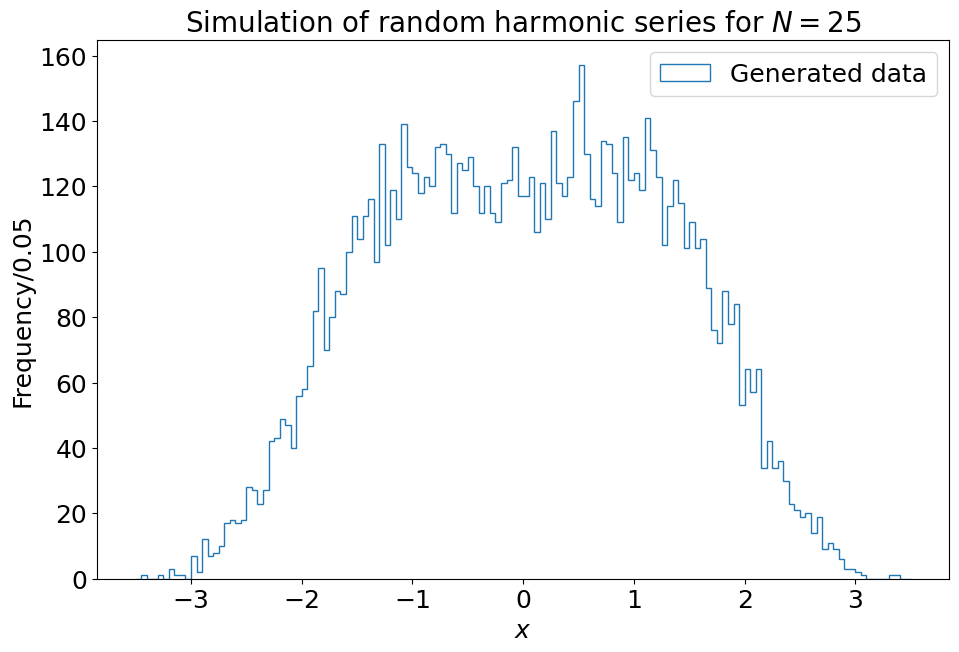

In [5]:
xmin = -3.5
xmax = 3.5
Nbins = 140
binwidth = (xmax - xmin)/Nbins
fig, ax = plt.subplots(figsize=(11,7))
ax.hist(x_vals, bins=Nbins, range=(xmin, xmax), histtype='step', label='Generated data')
ax.set_xlabel(r'$x$', fontsize=18)
ax.set_ylabel(f'Frequency/{binwidth:.2f}', fontsize=18)
ax.set_title('Simulation of random harmonic series for $N=25$', fontsize=20)
ax.legend(fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)

### PDF plotted on top

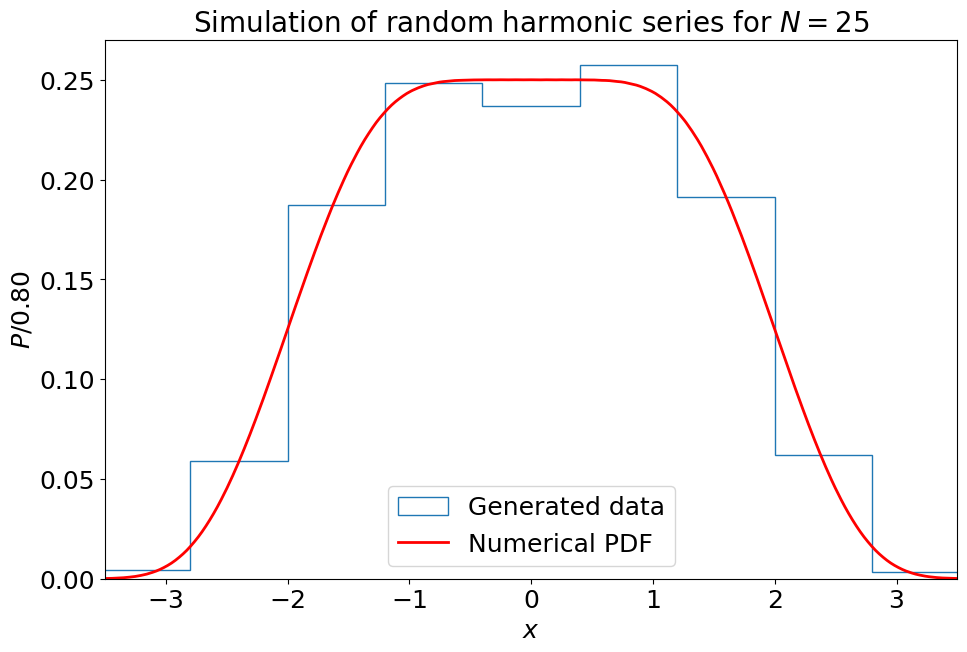

In [6]:
N = 25
T = 200
M = 2**14

t = np.linspace(-T, T, M)
phi = np.ones_like(t)

for n in range(1, N+1):
    phi *= np.cos(t / n)

pdf = np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(phi))).real
x = np.fft.fftshift(np.fft.fftfreq(M, d=(t[1]-t[0])/(2*np.pi)))

pdf /= np.trapezoid(pdf, x) # Normalization


xmin = -3.6
xmax = 3.6
Nbins = 9
binwidth = (xmax - xmin)/Nbins
fig, ax = plt.subplots(figsize=(11,7))
ax.hist(x_vals, bins=Nbins, density=True, range=(xmin, xmax), histtype='step', label='Generated data')
ax.plot(x, pdf, 'r', lw=2, label="Numerical PDF")
ax.set_xlabel(r'$x$', fontsize=18)
ax.set_ylabel(rf'$P/{binwidth:.2f}$', fontsize=18)
ax.set_title('Simulation of random harmonic series for $N=25$', fontsize=20)
ax.legend(fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.set_xlim(-3.5, 3.5);

## 3.1.2

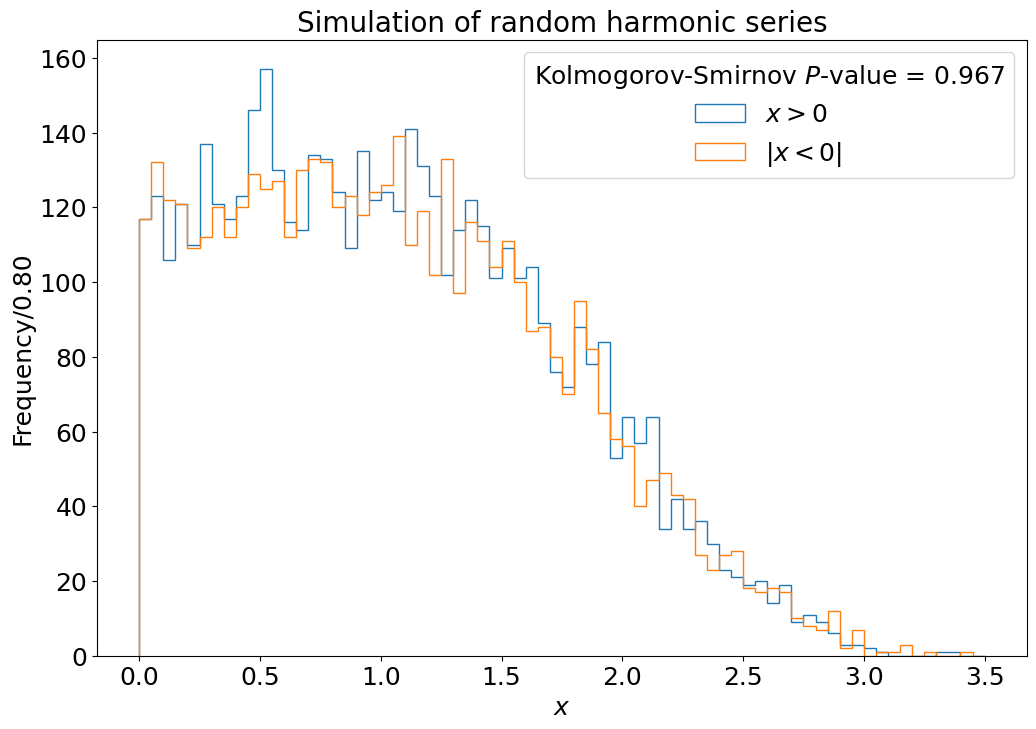

In [7]:
x_vals_neg = x_vals[x_vals < 0]
x_vals_pos = x_vals[x_vals > 0]
xmin = 0
xmax = 3.5
Nbins = 70
p_ks =stats.ks_2samp(x_vals_pos, -x_vals_neg)[1]
fit_info = [f"Kolmogorov-Smirnov $P$-value = {p_ks:.3f}",]

fig, ax = plt.subplots(figsize=(12,8))
ax.hist(x_vals_pos, bins=Nbins, range=(xmin, xmax), histtype='step', label=r'$x>0$')
ax.hist(-x_vals_neg, bins=Nbins, range=(xmin, xmax), histtype='step', label=r'$\vert x<0 \vert$')
ax.set_xlabel(r'$x$', fontsize=18)
ax.set_ylabel(f'Frequency/{binwidth:.2f}', fontsize=18)
ax.set_title('Simulation of random harmonic series', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=18)
plt.legend(title="\n".join(fit_info), fontsize=18, title_fontsize = 18, alignment = 'center');

In [8]:
r.seed(42)
p_sym = []
for i in range(500):
    x_vals_trial = np.sum(np.random.choice([-1, 1], size=(N_points, 25)) / np.arange(1, 25+1),axis=1)
    pos_x = x_vals_trial[x_vals_trial > 0]
    neg_x = x_vals_trial[x_vals_trial < 0]
    p_ks_trial = stats.ks_2samp(pos_x, -neg_x)[1]
    p_sym.append(p_ks_trial)

## 3.1.3

In [9]:
r.seed(42)
N_points = 10000
N = 250
x_vals_new = np.sum(np.random.choice([-1, 1], size=(N_points, N)) / np.arange(1, N+1),axis=1)

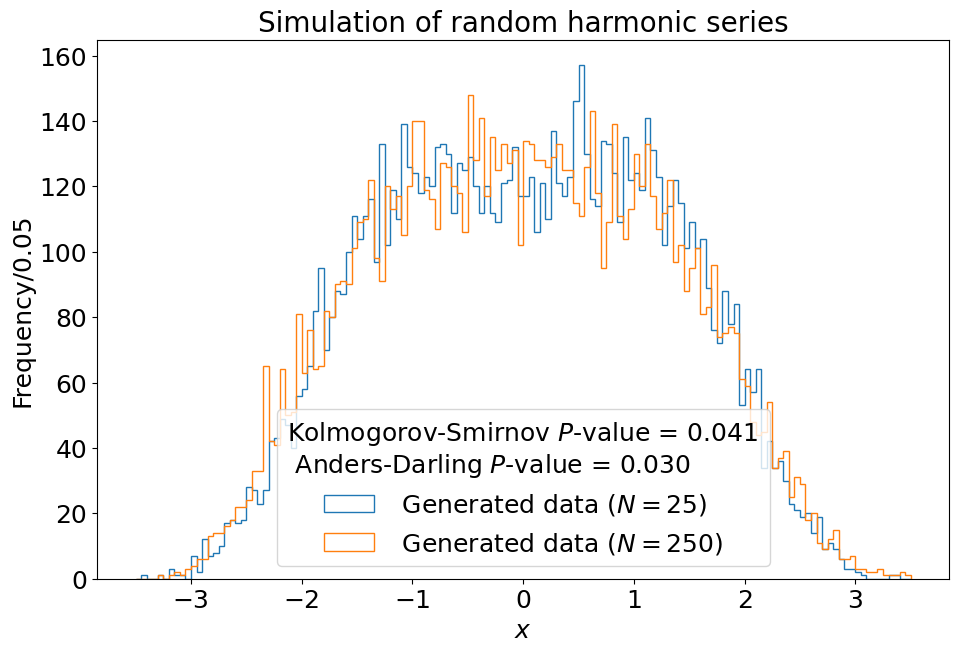

In [10]:
xmin = -3.5
xmax = 3.5
Nbins = 140
binwidth = (xmax - xmin)/Nbins
p_ks_new =stats.ks_2samp(x_vals, x_vals_new)[1]
result = stats.anderson_ksamp([x_vals, x_vals_new])
p_ad = result.pvalue
fit_info = [f"Kolmogorov-Smirnov $P$-value = {p_ks_new:.3f} \n Anders-Darling $P$-value = {p_ad:.3f}"]

fig, ax = plt.subplots(figsize=(11,7))
ax.hist(x_vals, bins=Nbins, range=(xmin, xmax), histtype='step', label=r' Generated data ($N=25$)')
ax.hist(x_vals_new, bins=Nbins, range=(xmin, xmax), histtype='step', label=r' Generated data ($N=250$)')
ax.set_xlabel(r'$x$', fontsize=18)
ax.set_ylabel(f'Frequency/{binwidth:.2f}', fontsize=18)
ax.set_title('Simulation of random harmonic series', fontsize=20)
ax.legend(fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)
plt.legend(title="\n".join(fit_info), fontsize=18, title_fontsize = 18, alignment = 'center');

In [11]:
result = stats.anderson_ksamp([x_vals, x_vals_new])

print("Anderson–Darling statistic:", result.statistic)
print("p-value:", result.pvalue)


Anderson–Darling statistic: 2.5260012316351177
p-value: 0.029943722824060152


In [12]:
mu25 = np.mean(x_vals)
mu250 = np.mean(x_vals_new)
print("Mean for N=25:", mu25)
print("Mean for N=250:", mu250)

Mean for N=25: 0.013690313243232145
Mean for N=250: -0.014694347463238236


In [13]:
r.seed(42)
p_vals_ks = []
p_vals_ad = []
N25 = 25
N250 = 250
for i in range(1000):
    x_vals_1 = np.sum(np.random.choice([-1, 1], size=(N_points, N25)) / np.arange(1, N25+1),axis=1)
    x_vals_2 = np.sum(np.random.choice([-1, 1], size=(N_points, N25)) / np.arange(1, N25+1),axis=1)
    p_vals_ks.append(stats.ks_2samp(x_vals_1, x_vals_2)[1])

KeyboardInterrupt: 

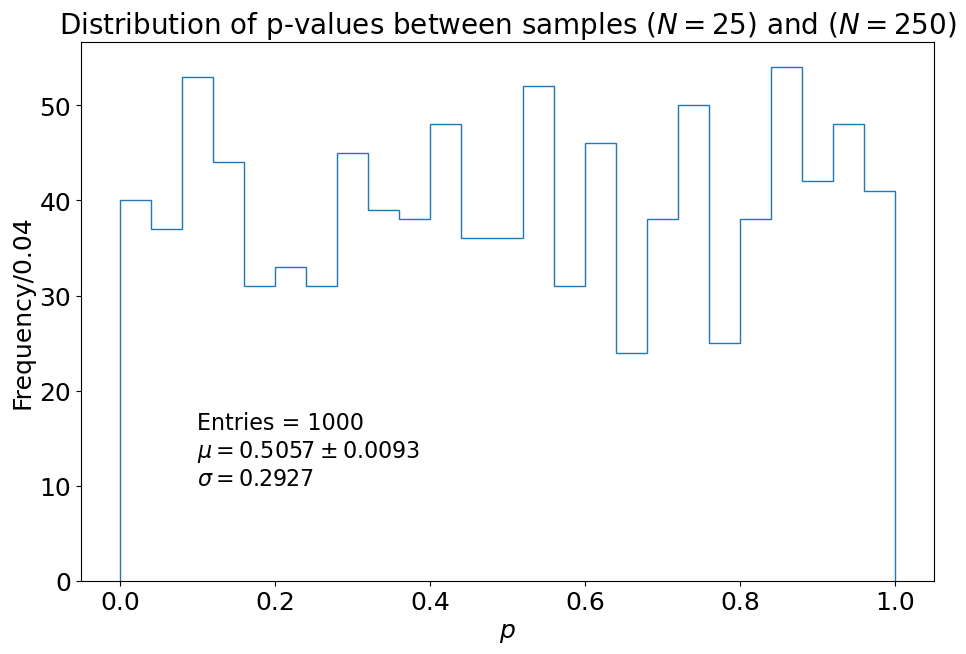

In [ ]:
xmin = 0
xmax = 1
Nbins = 25
binwidth = (xmax - xmin)/Nbins
mup, sigmap = compiler_esti(p_vals_ks)

fig, ax = plt.subplots(figsize=(11,7))
ax.hist(p_vals_ks, bins=Nbins, range=(xmin, xmax), histtype='step')
ax.set_xlabel(r'$p$', fontsize=18)
ax.set_ylabel(f'Frequency/{binwidth:.2f}', fontsize=18)
ax.set_title('Distribution of p-values between samples ($N=25$) and ($N=250$)', fontsize=20)
ax.text(0.1, 10, fr'Entries = {len(p_vals_ks)}' + '\n' + fr'$\mu={mup:.4f} \pm {sigmap:.4f}$' + '\n' + fr'$\sigma={np.std(p_vals_ks):.4f}$', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=18);

## 3.1.4

### KDE and effect of bin width

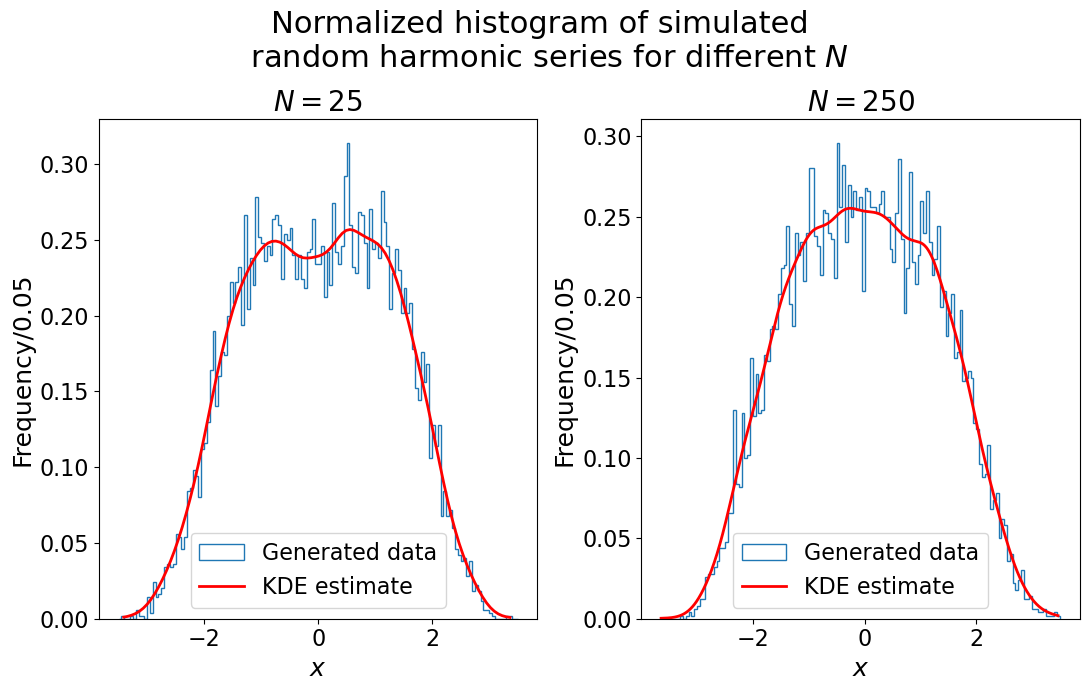

In [14]:
xmin = -3.5
xmax = 3.5
Nbins = 140
binwidth = (xmax - xmin)/Nbins

fig, ax = plt.subplots(1, 2, figsize=(11,7))
ax = ax.flatten()
kde = stats.gaussian_kde(x_vals)
x_grid = np.linspace(min(x_vals), max(x_vals), 100)
ax[0].hist(x_vals, bins=Nbins, density=True, range=(xmin, xmax), histtype='step', label='Generated data')
ax[0].plot(x_grid, kde(x_grid), 'r', lw=2, label='KDE estimate')
ax[0].set_xlabel(r'$x$', fontsize=18)
ax[0].set_ylabel(f'Frequency/{binwidth:.2f}', fontsize=18)
ax[0].set_title('$N=25$', fontsize=20)
ax[0].tick_params(axis='both', which='major', labelsize=16)
ax[0].legend(fontsize=16)

kde = stats.gaussian_kde(x_vals_new)
x_grid = np.linspace(min(x_vals_new), max(x_vals_new), 1000)
ax[1].hist(x_vals_new, bins=Nbins, density=True, range=(xmin, xmax), histtype='step', label='Generated data')
ax[1].plot(x_grid, kde(x_grid), 'r', lw=2, label='KDE estimate')
ax[1].set_xlabel(r'$x$', fontsize=18)
ax[1].set_ylabel(f'Frequency/{binwidth:.2f}', fontsize=18)
ax[1].set_title('$N=250$', fontsize=20)
ax[1].tick_params(axis='both', which='major', labelsize=16)
ax[1].legend(fontsize=16)

fig.suptitle('Normalized histogram of simulated \n random harmonic series for different $N$', fontsize=22);
plt.tight_layout()

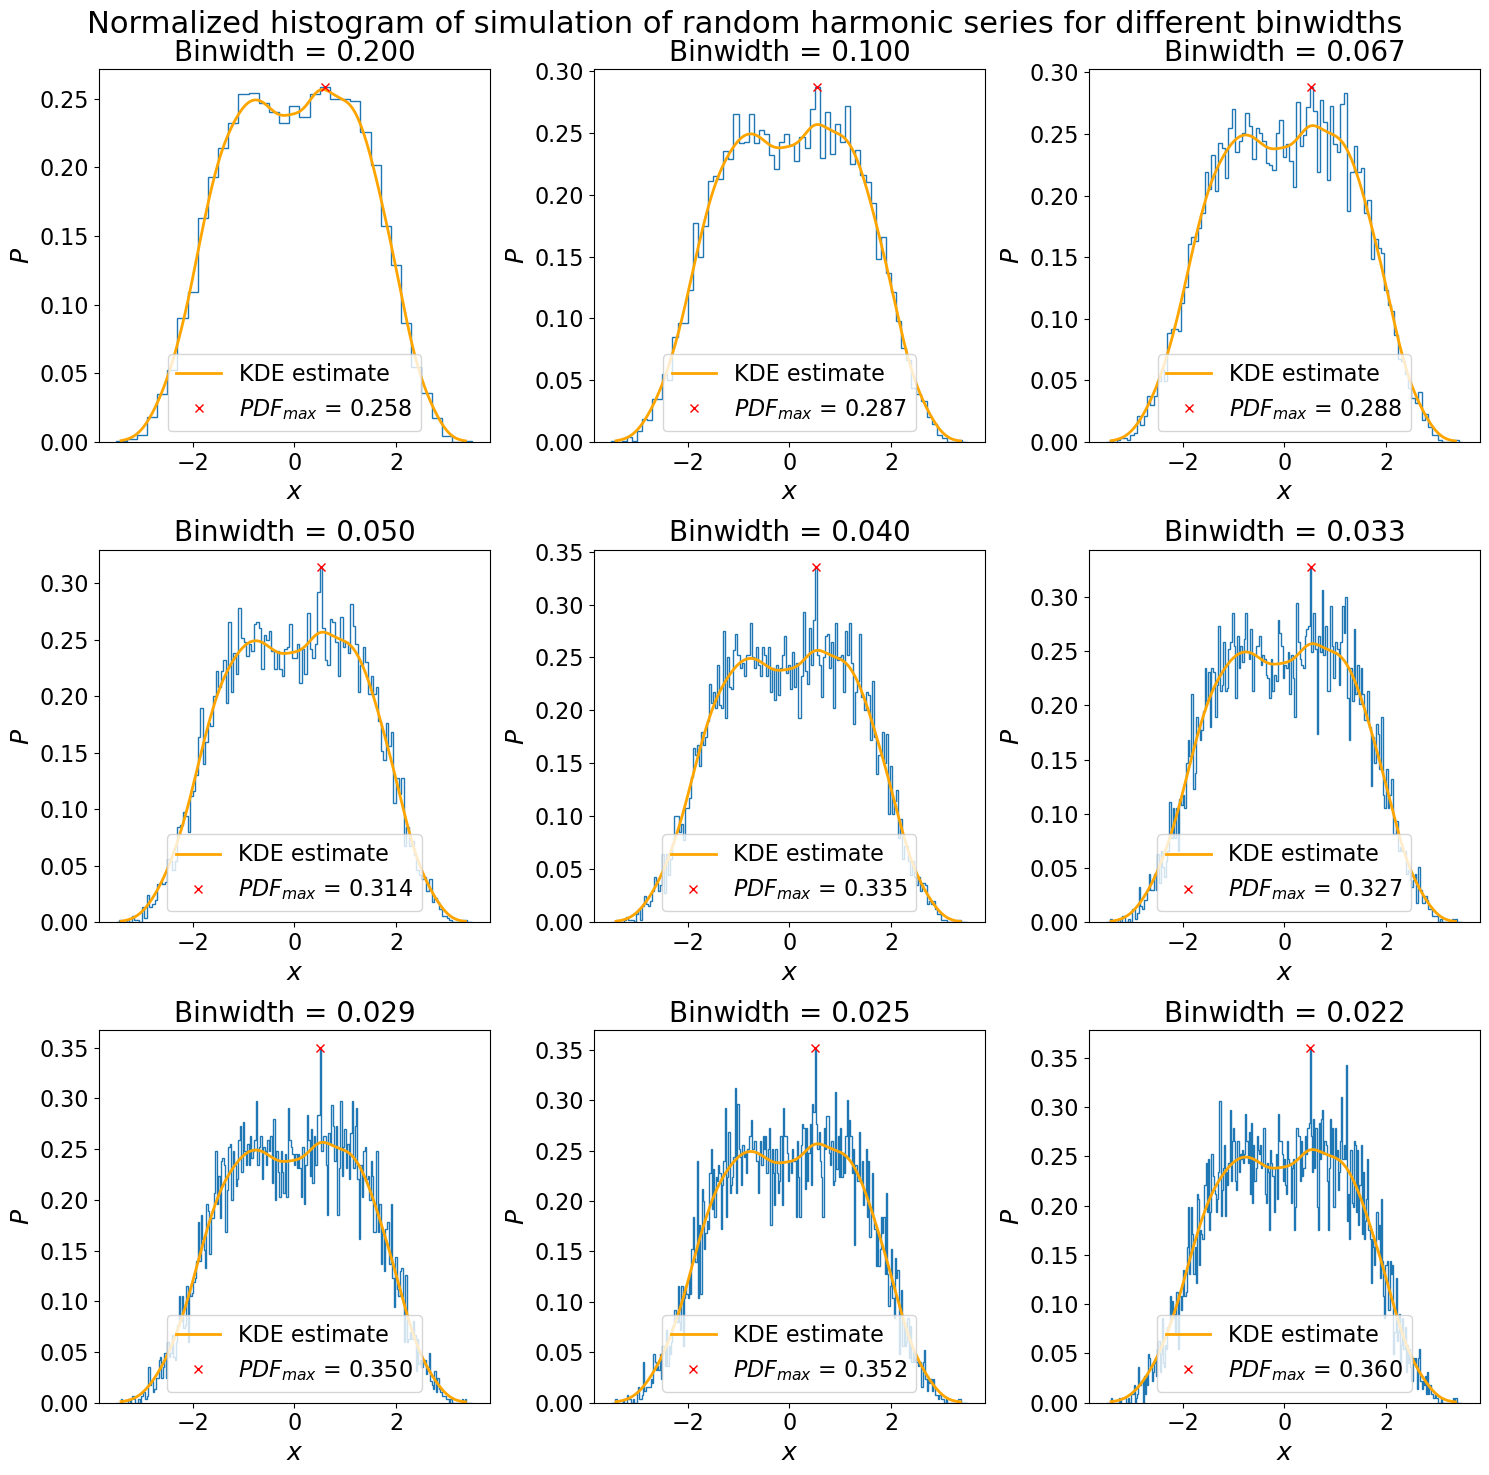

In [16]:
xmin = -3.5
xmax = 3.5
Nbins = 35
binwidth = (xmax - xmin)/Nbins
kde = stats.gaussian_kde(x_vals)
x_grid = np.linspace(min(x_vals), max(x_vals), 1000)

fig, ax = plt.subplots(3, 3, figsize=(15,15))
ax = ax.flatten()
for i in range(9):
    ax[i].hist(x_vals, bins=Nbins*(i+1), density=True, range=(xmin, xmax), histtype='step')
    ax[i].plot(x_grid, kde(x_grid), 'orange', lw=2, label='KDE estimate')
    counts, bin_edges = np.histogram(x_vals, bins=Nbins*(i+1), density=True, range=(xmin, xmax))
    x = (bin_edges[1:] + bin_edges[:-1])/2
    y = counts
    y_max = np.max(y)
    ax[i].plot(x[y==y_max], y_max, 'xr', lw=2, label=r'$PDF_{max}$' + f' = {y_max:.3f}')
    binwidth = (xmax - xmin)/(Nbins*(i+1))
    ax[i].set_xlabel(r'$x$', fontsize=18)
    ax[i].set_ylabel(r'$P$', fontsize=18)
    ax[i].set_title(f'Binwidth = {binwidth:.3f}', fontsize=20)
    ax[i].tick_params(axis='both', which='major', labelsize=16)
    ax[i].legend(fontsize=16, loc='lower center')

fig.suptitle('Normalized histogram of simulation of random harmonic series for different binwidths', fontsize=22);
plt.tight_layout()

### Simulation

In [ ]:
r.seed(42)
N_points = 10000
N_samples = 10000
xmin = -3.5
xmax = 3.5
Nbins = 140
binwidth_sample = (xmax - xmin)/Nbins

y_maxvals_hist25 = np.zeros(N_samples)
N = 25
for i in range(N_samples):
    samples = np.sum(np.random.choice([-1, 1], size=(N_points, N)) / np.arange(1, N+1),axis=1)
    counts, _ = np.histogram(samples, bins=Nbins, density=True, range=(xmin, xmax))
    y = counts
    y_max = np.max(y)
    y_maxvals_hist25[i] = y_max

y_maxvals_hist250 = np.zeros(N_samples)
N = 250
for i in range(N_samples):
    samples = np.sum(np.random.choice([-1, 1], size=(N_points, N)) / np.arange(1, N+1),axis=1)
    counts, _ = np.histogram(samples, bins=Nbins, density=True, range=(xmin, xmax))
    y = counts
    y_max = np.max(y)
    y_maxvals_hist250[i] = y_max

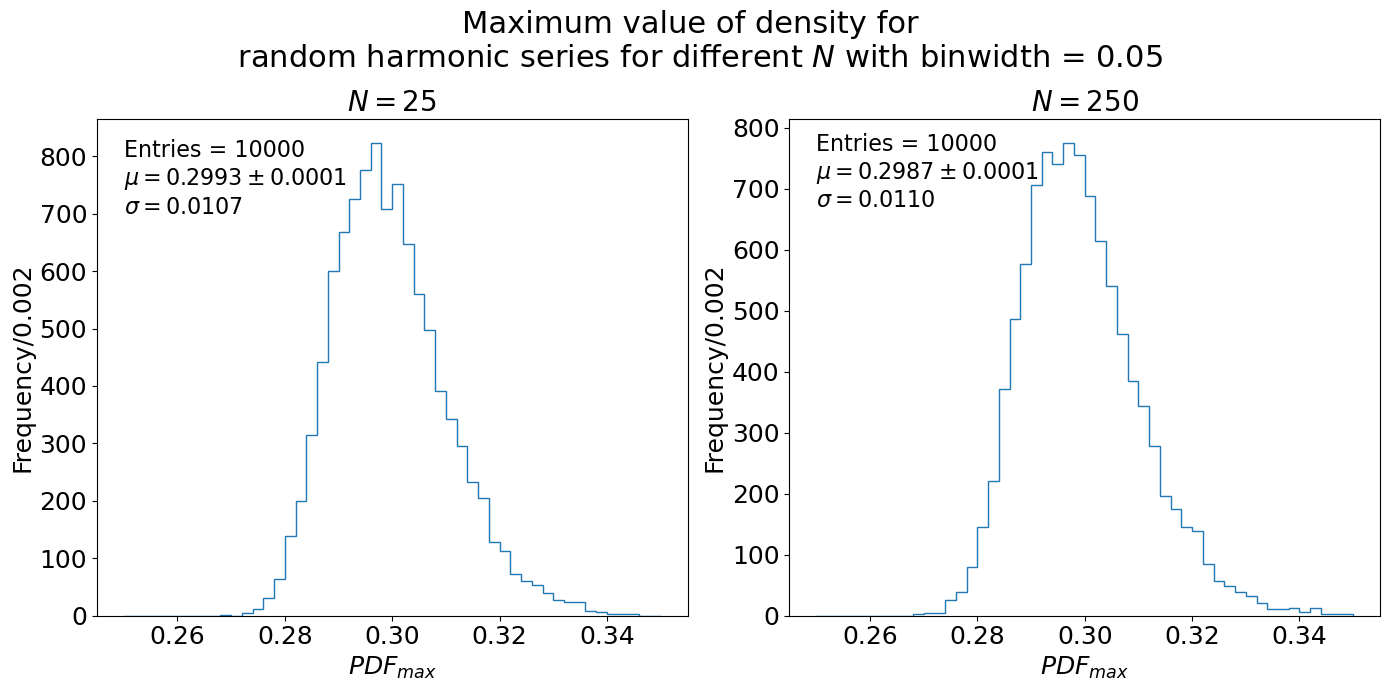

In [ ]:
mu_hist_25, unc_hist_25 = compiler_esti(y_maxvals_hist25)
mu_hist_250, unc_hist_250 = compiler_esti(y_maxvals_hist250)

xmin = 0.25
xmax = 0.35
Nbins = 50
binwidth = (xmax - xmin)/Nbins
fig, ax = plt.subplots(1, 2, figsize=(14,7))
ax = ax.flatten()

ax[0].hist(y_maxvals_hist25, bins=Nbins, range=(xmin, xmax), histtype='step')
ax[0].set_xlabel(r'$PDF_{max}$', fontsize=18)
ax[0].set_ylabel(f'Frequency/{binwidth:.3f}', fontsize=18)
ax[0].set_title('$N=25$', fontsize=20)
ax[0].text(0.25, 700, fr'Entries = {len(y_maxvals_hist25)}' + '\n' + fr'$\mu={mu_hist_25:.4f} \pm {unc_hist_25:.4f}$' + '\n' + fr'$\sigma={np.std(y_maxvals_hist25):.4f}$', fontsize=16)
ax[0].tick_params(axis='both', which='major', labelsize=18)

ax[1].hist(y_maxvals_hist250, bins=Nbins, range=(xmin, xmax), histtype='step')
ax[1].set_xlabel(r'$PDF_{max}$', fontsize=18)
ax[1].set_ylabel(f'Frequency/{binwidth:.3f}', fontsize=18)
ax[1].set_title('$N=250$', fontsize=20)
ax[1].text(0.25, 670, fr'Entries = {len(y_maxvals_hist250)}' + '\n' + fr'$\mu={mu_hist_250:.4f} \pm {unc_hist_250:.4f}$' + '\n' + fr'$\sigma={np.std(y_maxvals_hist250):.4f}$', fontsize=16)
ax[1].tick_params(axis='both', which='major', labelsize=18)

fig.suptitle(f'Maximum value of density for \n random harmonic series for different $N$ with binwidth = {binwidth_sample:.2f}', fontsize=22);
plt.tight_layout()

In [ ]:
r.seed(42)
N_points = 10000
N_samples = 1000
xmin = -3.5
xmax = 3.5
x_grid = np.linspace(xmin, xmax, 100)

y_maxvals_KDE25 = np.zeros(N_samples)
N = 25
for i in range(N_samples):
    samples = np.sum(np.random.choice([-1, 1], size=(N_points, N)) / np.arange(1, N+1),axis=1)
    kde = stats.gaussian_kde(samples)
    counts = kde(x_grid)
    y = counts
    y_max = np.max(y)
    y_maxvals_KDE25[i] = y_max

y_maxvals_KDE250 = np.zeros(N_samples)
N = 250
for i in range(N_samples):
    samples = np.sum(np.random.choice([-1, 1], size=(N_points, N)) / np.arange(1, N+1),axis=1)
    kde = stats.gaussian_kde(samples)
    counts = kde(x_grid)
    y = counts
    y_max = np.max(y)
    y_maxvals_KDE250[i] = y_max

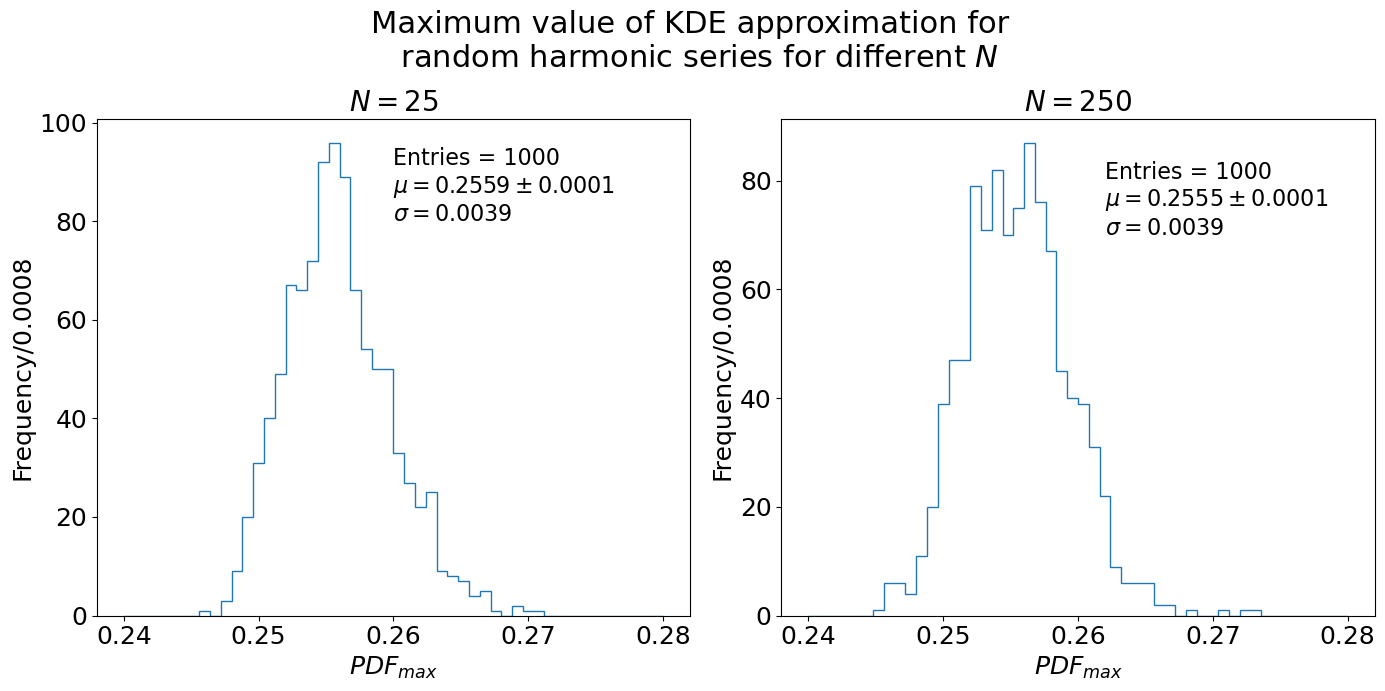

In [ ]:
mu_kde_25, unc_kde_25 = compiler_esti(y_maxvals_KDE25)
mu_kde_250, unc_kde_250 = compiler_esti(y_maxvals_KDE250)

xmin = 0.24
xmax = 0.28
Nbins = 50
binwidth = (xmax - xmin)/Nbins
fig, ax = plt.subplots(1, 2, figsize=(14,7))
ax = ax.flatten()

ax[0].hist(y_maxvals_KDE25, bins=Nbins, range=(xmin, xmax), histtype='step')
ax[0].set_xlabel(r'$PDF_{max}$', fontsize=18)
ax[0].set_ylabel(f'Frequency/{binwidth:.4f}', fontsize=18)
ax[0].set_title('$N=25$', fontsize=20)
ax[0].text(0.26, 80, fr'Entries = {len(y_maxvals_KDE25)}' + '\n' + fr'$\mu={mu_kde_25:.4f} \pm {unc_kde_25:.4f}$' + '\n' + fr'$\sigma={np.std(y_maxvals_KDE25):.4f}$', fontsize=16)
ax[0].tick_params(axis='both', which='major', labelsize=18)

ax[1].hist(y_maxvals_KDE250, bins=Nbins, range=(xmin, xmax), histtype='step')
ax[1].set_xlabel(r'$PDF_{max}$', fontsize=18)
ax[1].set_ylabel(f'Frequency/{binwidth:.4f}', fontsize=18)
ax[1].set_title('$N=250$', fontsize=20)
ax[1].text(0.262, 70, fr'Entries = {len(y_maxvals_KDE250)}' + '\n' + fr'$\mu={mu_kde_250:.4f} \pm {unc_kde_250:.4f}$' + '\n' + fr'$\sigma={np.std(y_maxvals_KDE250):.4f}$', fontsize=16)
ax[1].tick_params(axis='both', which='major', labelsize=18)

fig.suptitle(f'Maximum value of KDE approximation for \n random harmonic series for different $N$', fontsize=22);
plt.tight_layout()

In [ ]:
r.seed(42)
N_points = 10000
N_samples = 10000
xmin = -3.5
xmax = 3.5
Nbins = 35
binwidth_large = (xmax - xmin)/Nbins

y_maxvals_hist25_2 = np.zeros(N_samples)
N = 25
for i in range(N_samples):
    samples = np.sum(np.random.choice([-1, 1], size=(N_points, N)) / np.arange(1, N+1),axis=1)
    counts, _ = np.histogram(samples, bins=Nbins, density=True, range=(xmin, xmax))
    y = counts
    y_max = np.max(y)
    y_maxvals_hist25_2[i] = y_max

y_maxvals_hist250_2 = np.zeros(N_samples)
N = 250
for i in range(N_samples):
    samples = np.sum(np.random.choice([-1, 1], size=(N_points, N)) / np.arange(1, N+1),axis=1)
    counts, _ = np.histogram(samples, bins=Nbins, density=True, range=(xmin, xmax))
    y = counts
    y_max = np.max(y)
    y_maxvals_hist250_2[i] = y_max

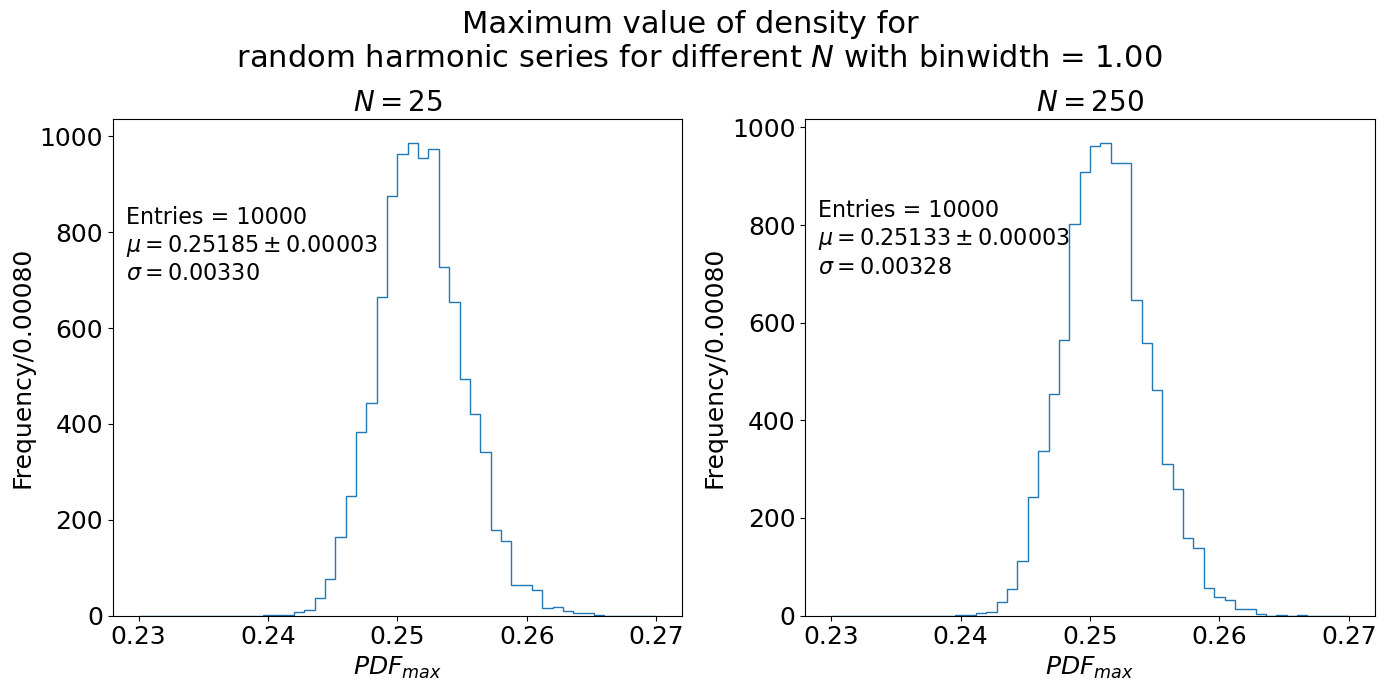

In [ ]:
mu_hist_25_2, unc_hist_25_2 = compiler_esti(y_maxvals_hist25_2)
mu_hist_250_2, unc_hist_250_2 = compiler_esti(y_maxvals_hist250_2)

xmin = 0.23
xmax = 0.27
Nbins = 50
binwidth = (xmax - xmin)/Nbins

fig, ax = plt.subplots(1, 2, figsize=(14,7))
ax = ax.flatten()

ax[0].hist(y_maxvals_hist25_2, bins=Nbins, range=(xmin, xmax), histtype='step')
ax[0].set_xlabel(r'$PDF_{max}$', fontsize=18)
ax[0].set_ylabel(f'Frequency/{binwidth:.5f}', fontsize=18)
ax[0].set_title('$N=25$', fontsize=20)
ax[0].text(0.229, 700, fr'Entries = {len(y_maxvals_hist25_2)}' + '\n' + fr'$\mu={mu_hist_25_2:.5f} \pm {unc_hist_25_2:.5f}$' + '\n' + fr'$\sigma={np.std(y_maxvals_hist25_2):.5f}$', fontsize=16)
ax[0].tick_params(axis='both', which='major', labelsize=18)

ax[1].hist(y_maxvals_hist250_2, bins=Nbins, range=(xmin, xmax), histtype='step')
ax[1].set_xlabel(r'$PDF_{max}$', fontsize=18)
ax[1].set_ylabel(f'Frequency/{binwidth:.5f}', fontsize=18)
ax[1].set_title('$N=250$', fontsize=20)
ax[1].text(0.229, 700, fr'Entries = {len(y_maxvals_hist250_2)}' + '\n' + fr'$\mu={mu_hist_250_2:.5f} \pm {unc_hist_250_2:.5f}$' + '\n' + fr'$\sigma={np.std(y_maxvals_hist250_2):.5f}$', fontsize=16)
ax[1].tick_params(axis='both', which='major', labelsize=18)

fig.suptitle(f'Maximum value of density for \n random harmonic series for different $N$ with binwidth = {binwidth_large:.2f}', fontsize=22);
plt.tight_layout()

In [ ]:
r.seed(42)
N = 25
T = 200
M = 2**14
t = np.linspace(-T, T, M)
phi = np.ones_like(t)

for n in range(1, N+1):
    phi *= np.cos(t / n)
pdf = np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(phi))).real
x = np.fft.fftshift(np.fft.fftfreq(M, d=(t[1]-t[0])/(2*np.pi)))

pdf /= np.trapezoid(pdf, x) # Normalization
(np.max(pdf)-0.25)/0.25*100

np.float64(0.02326967119417045)

In [ ]:
mu_vals = np.array([mu_hist_25, mu_hist_250, mu_kde_25, mu_kde_250, mu_hist_25_2, mu_hist_250_2])
unc_vals = np.array([unc_hist_25, unc_hist_250, unc_kde_25, unc_kde_250, unc_hist_25_2, unc_hist_250_2])
for i in range(len(mu_vals)):
    z = np.abs(0.25-mu_vals[i])/unc_vals[i]
    print(f"Estimate {i+1} -> mu = {mu_vals[i]:.5f} ± {unc_vals[i]:.5f}, sigmas away = {z:.2f}")

Estimate 1 -> mu = 0.29933 ± 0.00011, sigmas away = 459.13
Estimate 2 -> mu = 0.29869 ± 0.00011, sigmas away = 442.05
Estimate 3 -> mu = 0.25593 ± 0.00012, sigmas away = 48.49
Estimate 4 -> mu = 0.25549 ± 0.00012, sigmas away = 44.74
Estimate 5 -> mu = 0.26669 ± 0.00006, sigmas away = 270.86
Estimate 6 -> mu = 0.26618 ± 0.00006, sigmas away = 259.75
